In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# 2. Load Dataset
df = pd.read_csv('../datasets/master_dataset.csv')
df.head()

,gender,number_of_dependents,education_level,employment_type,monthly_income,loan_amount_requested,loan_tenure_months,area_type,loan_type,loan_status,data_source,credit_score,total_assets_value,liquid_assets_value,savings_balance,application_id,age,marital_status,occupation,income_type,state,loan_purpose,existing_emi,is_synthetic_age,is_synthetic_gender,is_synthetic_marital_status,is_synthetic_occupation,is_synthetic_employment_type,is_synthetic_income_type,is_synthetic_area_type,is_synthetic_credit_score,is_synthetic_existing_emi,is_synthetic_savings_balance,is_synthetic_total_assets_value,is_synthetic_liquid_assets_value,is_synthetic_state,is_synthetic_loan_purpose,loan_to_income_ratio,debt_to_income_ratio
0,Male,0.0,Undergraduate,Full-Time,5849.0,130000.0,360.0,Urban,Home Loan,1,ds1_loan_prediction,707.979123,45474.754735,21923.669174,15557.398017,1,36.0,Single,Retail & Customer Service,Salary,Delhi,Home Renovation,282.981543,True,False,True,True,True,True,False,True,True,True,True,True,True,True,1.852168,0.048381
1,Male,1.0,Undergraduate,Full-Time,4583.0,128000.0,360.0,Rural,Home Loan,0,ds1_loan_prediction,688.936366,7862.286029,2544.364992,5256.473685,2,38.0,Married,Student,Salary,Telangana,Home Renovation,242.938304,True,False,True,True,True,True,False,True,True,True,True,True,True,True,2.327442,0.053009
2,Male,0.0,Undergraduate,Self-Employed,3000.0,66000.0,360.0,Urban,Home Loan,1,ds1_loan_prediction,705.258333,49801.741269,22449.089062,2777.835148,3,41.0,Married,Retail & Customer Service,Self-Employment Income,Chandigarh,Home Purchase,298.448686,True,False,True,True,False,True,False,True,True,True,True,True,True,True,1.833333,0.099483
3,Male,0.0,Higher Secondary,Full-Time,2583.0,120000.0,360.0,Urban,Home Loan,1,ds1_loan_prediction,747.946895,12449.149023,3070.245124,2682.233512,4,22.0,Married,Construction,Salary,Sikkim,Home Renovation,31.792730,True,False,True,True,True,True,False,True,True,True,True,True,True,True,3.871467,0.012308
4,Male,0.0,Undergraduate,Full-Time,6000.0,141000.0,360.0,Urban,Home Loan,1,ds1_loan_prediction,684.646855,40984.662851,12097.525601,15393.013341,5,32.0,Single,Government Services,Salary,Nagaland,Home Renovation,590.967839,True,False,True,True,True,True,False,True,True,True,True,True,True,True,1.958333,0.098495


In [2]:
# 3. Basic Dataset Information
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4883 entries, 0 to 4882
Data columns (total 39 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   gender                            4883 non-null   object 
 1   number_of_dependents              4883 non-null   float64
 2   education_level                   4883 non-null   object 
 3   employment_type                   4883 non-null   object 
 4   monthly_income                    4883 non-null   float64
 5   loan_amount_requested             4883 non-null   float64
 6   loan_tenure_months                4883 non-null   float64
 7   area_type                         4883 non-null   object 
 8   loan_type                         4883 non-null   object 
 9   loan_status                       4883 non-null   int64  
 10  data_source                       4883 non-null   object 
 11  credit_score                      4883 non-null   float64
 12  total_

,number_of_dependents,monthly_income,loan_amount_requested,loan_tenure_months,loan_status,credit_score,total_assets_value,liquid_assets_value,savings_balance,application_id,age,existing_emi,loan_to_income_ratio,debt_to_income_ratio
count,4883.000000,4883.000000,4.883000e+03,4883.000000,4883.000000,4883.000000,4.883000e+03,4.883000e+03,4.883000e+03,4883.000000,4883.000000,4883.000000,4883.000000,4883.000000
mean,2.283842,369260.916923,1.324870e+07,157.413066,0.630350,610.948821,2.846200e+07,1.757733e+07,4.352372e+06,2442.000000,35.070244,23904.161643,3.003019,0.065077
std,1.731021,258611.944382,9.808206e+06,97.713501,0.482759,166.160528,2.118485e+07,1.291685e+07,3.456259e+06,1409.745012,8.527072,34995.665067,1.526802,0.068376
min,0.000000,150.000000,9.000000e+03,12.000000,0.000000,300.000000,8.133751e+02,3.883453e+02,0.000000e+00,1.000000,21.000000,0.000000,0.168411,0.000000
25%,1.000000,133333.333333,4.600000e+06,72.000000,0.000000,471.000000,9.500000e+06,6.100000e+06,1.400000e+06,1221.500000,29.000000,0.000000,2.418762,0.000000
50%,2.000000,366666.666667,1.250000e+07,144.000000,1.000000,632.000000,2.720000e+07,1.710000e+07,3.900000e+06,2442.000000,35.000000,6398.802433,2.948718,0.049939
75%,4.000000,591666.666667,2.050000e+07,216.000000,1.000000,742.000000,4.435000e+07,2.780000e+07,6.600000e+06,3662.500000,41.000000,36279.140837,3.500000,0.109130
max,5.000000,825000.000000,3.950000e+07,480.000000,1.000000,900.000000,9.070000e+07,5.380000e+07,1.470000e+07,4883.000000,65.000000,266853.988095,75.000000,0.374628


In [3]:
# 4. Missing Values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_values, missing_percentage

(gender                              0
 number_of_dependents                0
 education_level                     0
 employment_type                     0
 monthly_income                      0
 loan_amount_requested               0
 loan_tenure_months                  0
 area_type                           0
 loan_type                           0
 loan_status                         0
 data_source                         0
 credit_score                        0
 total_assets_value                  0
 liquid_assets_value                 0
 savings_balance                     0
 application_id                      0
 age                                 0
 marital_status                      0
 occupation                          0
 income_type                         0
 state                               0
 loan_purpose                        0
 existing_emi                        0
 is_synthetic_age                    0
 is_synthetic_gender                 0
 is_synthetic_marital_sta

In [4]:
# 5. Duplicate Rows
df.duplicated().sum()

0

loan_status
1    3078
0    1805
Name: count, dtype: int64
loan_status
1    0.63035
0    0.36965
Name: proportion, dtype: float64


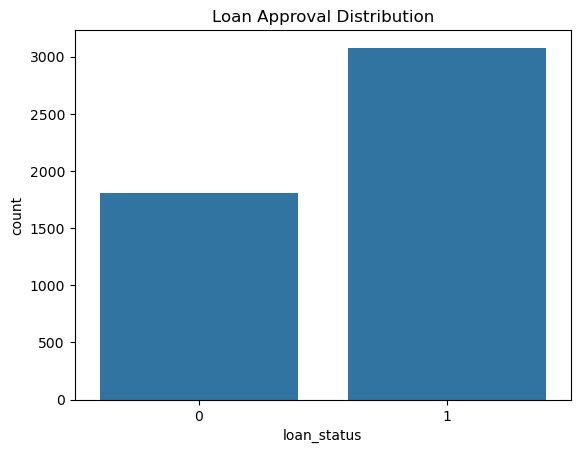

In [5]:
# 6. Target Variable Analysis
if 'loan_status' in df.columns:
    print(df['loan_status'].value_counts())
    print(df['loan_status'].value_counts(normalize=True))
    sns.countplot(data=df, x='loan_status')
    plt.title('Loan Approval Distribution')
    plt.show()

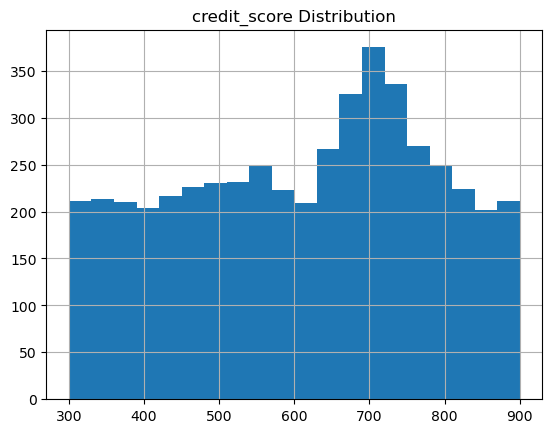

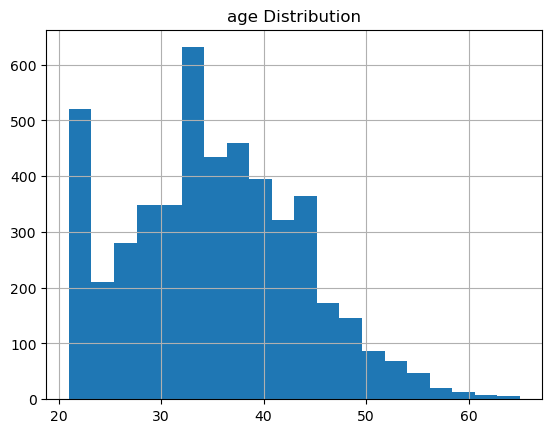

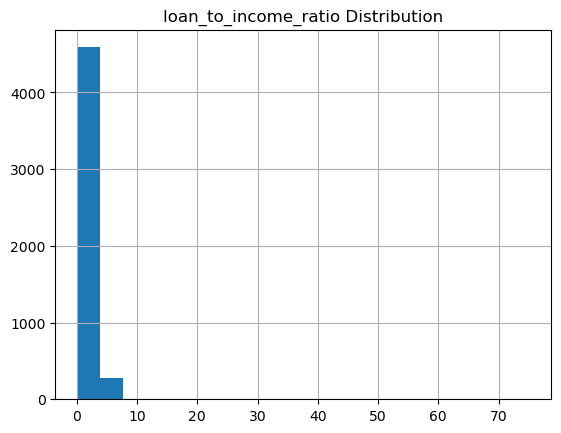

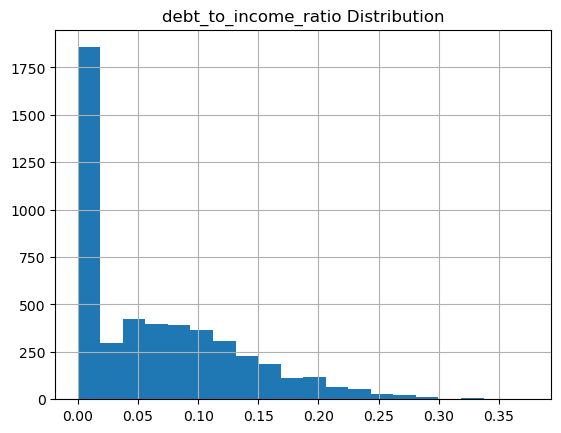

In [6]:
# 7. Numerical Feature Analysis
numerical_columns = df.select_dtypes(include=np.number).columns
numerical_columns

for col in ['credit_score', 'age', 'income', 'loan_amount', 'emi', 'loan_to_income_ratio', 'debt_to_income_ratio']:
    if col in df.columns:
        df[col].hist(bins=20)
        plt.title(f'{col} Distribution')
        plt.show()

In [7]:
# 8. Categorical Feature Analysis
categorical_columns = df.select_dtypes(include='object').columns
categorical_columns

for col in ['employment_type', 'occupation', 'state', 'education', 'loan_type', 'loan_purpose']:
    if col in df.columns:
        print(f'\n{col}:')
        print(df[col].value_counts().head(10))


employment_type:
employment_type
Self-Employed    2232
Full-Time        2024
Part-Time         297
Contract          208
Temporary         122
Name: count, dtype: int64

occupation:
occupation
Business & Management        930
Other                        731
Engineering & Technology     501
Sales & Marketing            499
Finance & Accounting         390
Manufacturing                347
Healthcare                   319
Construction                 318
Government Services          305
Retail & Customer Service    137
Name: count, dtype: int64

state:
state
Andaman and Nicobar Islands    161
Lakshadweep                    158
Karnataka                      158
Jharkhand                      152
Maharashtra                    152
Arunachal Pradesh              150
Chhattisgarh                   146
Mizoram                        146
Gujarat                        141
Tamil Nadu                     140
Name: count, dtype: int64

loan_type:
loan_type
Home Loan        3728
Business Loan   

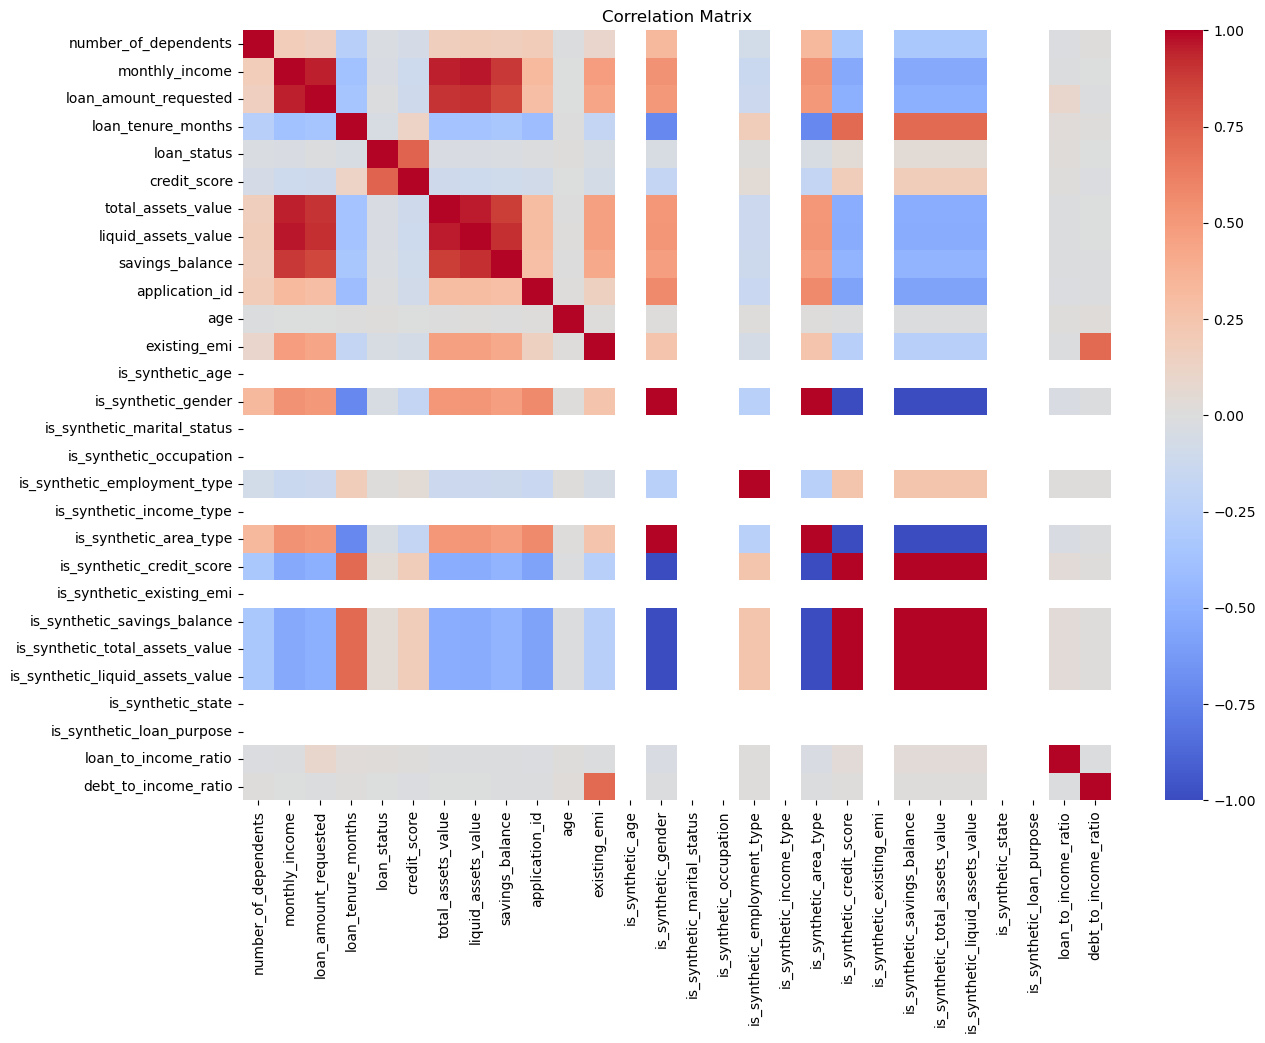

In [8]:
# 9. Correlation Analysis
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(correlation, cmap='coolwarm', annot=False)
plt.title('Correlation Matrix')
plt.show()

In [9]:
# 10. Initial Observations

# Write your observations here after reviewing the outputs.
# Example:
# - Dataset contains many applicants and multiple features.
# - Missing values and duplicate rows should be checked.
# - The target variable appears to be loan_status.
# - Numerical and categorical features should be treated differently during preprocessing.